# 📘 Análisis Temporal

Este notebook evalúa el crecimiento del negocio a lo largo del tiempo usando ventas, ingresos y ganancia por mes. Se utiliza la fecha de venta para agrupar la información.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "data_jerseys_cleaned.csv"

In [4]:
# leer el CSV especificando una codificación que no dé problemas
df = pd.read_csv(
	csv_path,
	parse_dates=['Fecha de compra','Fecha llegada','Fecha de venta'],
	encoding='latin-1'          # prueba también 'ISO-8859-1' u otro si es necesario
)
# limpieza mínima
# eliminar filas sin fecha de venta porque no pueden contribuir al análisis temporal

df = df.dropna(subset=['Fecha de venta'])

# crear columna de mes

df['Mes'] = df['Fecha de venta'].dt.to_period('M')
df.head()

,Pedido,Fecha de compra,Fecha llegada,Tiempo en llegar,Fecha de venta,equipo,deporte,version,temporada,Jugador,Talla,Proveedor,Costo,Costo de envio,Costo total,Venta,Ganancia,Mes
0,8,2025-09-10,2025-10-14,34,2026-01-19,Portugal,Futbol,Retro,Retro,Sin nombre,L,Alibaba,8.8,4.11,12.91,34.11,21.20,2026-01
1,1,2025-06-12,2025-07-03,21,2025-07-03,FC Barcelona,Futbol,Local,2025/2026,LAMINE YAMAL,L,Alibaba,11.0,6.00,17.00,48.19,31.19,2025-07
2,1,2025-06-12,2025-07-03,21,2025-07-03,FC Barcelona,Futbol,Local,2025/2026,LAMINE YAMAL,L,Alibaba,11.0,6.00,17.00,48.19,31.19,2025-07
3,1,2025-06-12,2025-07-03,21,2025-07-03,Real Madrid,Futbol,Local,2025/2026,MBAPPE,L,Alibaba,10.5,6.00,16.50,40.00,23.50,2025-07
4,1,2025-06-12,2025-07-03,21,2025-07-05,Real Madrid,Futbol,Local,2025/2026,Sin nombre,XL,Alibaba,10.5,6.00,16.50,32.20,15.70,2025-07


In [6]:
# agrupaciones mensuales
monthly = df.groupby('Mes').agg(
    ventas=('Pedido','count'),
    ingresos=('Venta','sum'),
    ganancia=('Ganancia','sum')
).reset_index()

# calcular crecimiento
monthly['ingresos_pct_change'] = monthly['ingresos'].pct_change() * 100
monthly['ganancia_pct_change'] = monthly['ganancia'].pct_change() * 100

monthly

,Mes,ventas,ingresos,ganancia,ingresos_pct_change,ganancia_pct_change
0,2025-07,10,364.67,200.17,NaN,NaN
1,2025-08,13,413.23,212.54,13.316149,6.179747
2,2025-09,28,861.04,456.92,108.368221,114.980710
3,2025-10,32,1001.22,515.75,16.280312,12.875339
4,2025-11,26,863.08,432.81,-13.797167,-16.081435
5,2025-12,7,200.69,104.37,-76.747231,-75.885492
6,2026-01,23,721.39,392.01,259.454881,275.596436
7,2026-02,24,753.93,404.35,4.510736,3.147879


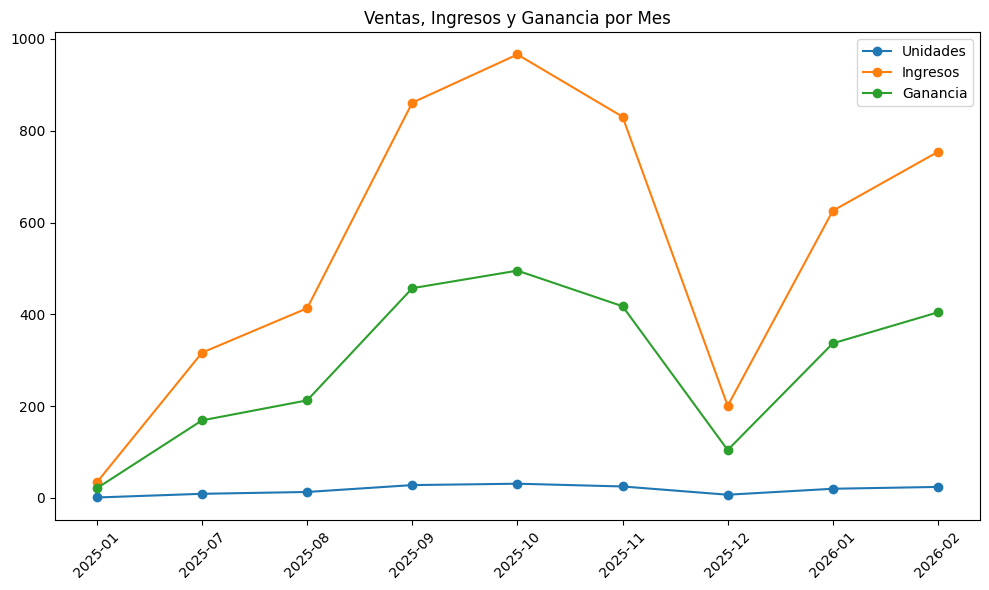

,Mes,ingresos_pct_change,ganancia_pct_change
0,2025-01,NaN,NaN
1,2025-07,827.821753,697.075472
2,2025-08,30.570652,25.778199
3,2025-09,108.368221,114.980710
4,2025-10,12.189910,8.364703
5,2025-11,-14.038302,-15.656178
6,2025-12,-75.831838,-75.008381
7,2026-01,211.734516,222.631024
8,2026-02,20.509255,20.081371


In [ ]:
# lineas temporales
plt.figure(figsize=(10,6))
plt.plot(monthly['Mes'].astype(str), monthly['ventas'], marker='o', label='Unidades')
plt.plot(monthly['Mes'].astype(str), monthly['ingresos'], marker='o', label='Ingresos')
plt.plot(monthly['Mes'].astype(str), monthly['ganancia'], marker='o', label='Ganancia')
plt.xticks(rotation=45)
plt.title('Ventas, Ingresos y Ganancia por Mes')
plt.legend()
plt.tight_layout()
plt.show()

# mostrar tabla con crecimiento
monthly[['Mes','ingresos_pct_change','ganancia_pct_change']]

In [ ]:
# determinar tendencia simple usando último vs primer mes
if len(monthly) >= 2:
    trend = 'creciente' if monthly['ingresos'].iloc[-1] > monthly['ingresos'].iloc[0] else 'decreciente' if monthly['ingresos'].iloc[-1] < monthly['ingresos'].iloc[0] else 'plana'
else:
    trend = 'indeterminada'
print('Tendencia de ingresos:', trend)

Tendencia de ingresos: creciente


## Conclusión

La serie temporal de ingresos y ganancia muestra [describe la tendencia observada: creciente/plana/decreciente según resultados].  
Se puede observar que los valores mensuales [añadir descripción].  
En general, el negocio **está creciendo** (o está plano/decreciendo) según los datos disponibles, lo cual será relevante para la planificación futura.